In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

train_df   = pd.read_csv('/content/train.csv',            parse_dates=['date'])
test_df    = pd.read_csv('/content/test.csv',             parse_dates=['date'])
stores_df  = pd.read_csv('/content/stores.csv')
oil_df     = pd.read_csv('/content/oil.csv',              parse_dates=['date'])
holiday_df = pd.read_csv('/content/holidays_events.csv',  parse_dates=['date'])
trans_df   = pd.read_csv('/content/transactions.csv',     parse_dates=['date'])

print("All files loaded successfully!")
print(f"  train_df:   {len(train_df):,} rows")
print(f"  test_df:    {len(test_df):,} rows")
print(f"  stores_df:  {len(stores_df):,} rows")
print(f"  oil_df:     {len(oil_df):,} rows")
print(f"  holiday_df: {len(holiday_df):,} rows")
print(f"  trans_df:   {len(trans_df):,} rows")

All files loaded successfully!
  train_df:   3,000,888 rows
  test_df:    28,512 rows
  stores_df:  54 rows
  oil_df:     1,218 rows
  holiday_df: 350 rows
  trans_df:   83,488 rows


# SECTION 1 — QUERY

In [ ]:
#BUSINESS QUERIES:
  #Q1. What will sales be for the next 15 days per store?
  #Q2. Which product families drive the most revenue?
  #Q3. How do oil prices affect grocery sales?
  #Q4. What is the impact of holidays on sales volume?
  #Q5. Which stores perform best and worst?
  #Q6. Is there a seasonal pattern in sales?
  #Q7. How accurate can our forecasting model be?

### SECTION 2 — DATA EXPLORATION

In [19]:
print(f"  train.csv:            {len(train_df):>10,} rows")
print(f"  test.csv:             {len(test_df):>10,} rows")
print(f"  stores.csv:           {len(stores_df):>10,} rows")
print(f"  oil.csv:              {len(oil_df):>10,} rows")
print(f"  holidays_events.csv:  {len(holiday_df):>10,} rows")
print(f"  transactions.csv:     {len(trans_df):>10,} rows")

print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(train_df.head().to_string(index=False))
print(f"\nDate range: {train_df['date'].min().date()} → {train_df['date'].max().date()}")
print(f"Stores:     {train_df['store_nbr'].nunique()}")
print(f"Families:   {train_df['family'].nunique()}")
print(f"Total sales:{train_df['sales'].sum():,.0f} units")

print(f"\nMissing values:")
for df_name, df in [("train", train_df), ("oil", oil_df), ("holiday", holiday_df)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"  {df_name}: {nulls.to_dict()}")
    else:
        print(f"  {df_name}: no missing values")


  train.csv:             3,000,888 rows
  test.csv:                 28,512 rows
  stores.csv:                   54 rows
  oil.csv:                   1,218 rows
  holidays_events.csv:         350 rows
  transactions.csv:         83,488 rows

Train columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

First 5 rows:
 id       date  store_nbr     family  sales  onpromotion
  0 2013-01-01          1 AUTOMOTIVE    0.0            0
  1 2013-01-01          1  BABY CARE    0.0            0
  2 2013-01-01          1     BEAUTY    0.0            0
  3 2013-01-01          1  BEVERAGES    0.0            0
  4 2013-01-01          1      BOOKS    0.0            0

Date range: 2013-01-01 → 2017-08-15
Stores:     54
Families:   33
Total sales:1,073,644,952 units

Missing values:
  train: no missing values
  oil: {'dcoilwtico': 43}
  holiday: no missing values


## SECTION 3-OBJECTIVE

OBJECTIVE 1 — DEMAND FORECASTING
  Forecast daily sales for next 15 days per store and family.
  SUCCESS: RMSE and RMSLE minimised vs baseline naive model.

OBJECTIVE 2 — EXTERNAL FACTOR ANALYSIS
  Quantify impact of oil prices and holidays on sales.
  SUCCESS: Clear correlation identified and quantified.

OBJECTIVE 3 — STORE PERFORMANCE ANALYSIS
  Rank stores by sales volume, growth, and efficiency.
  SUCCESS: Top and bottom 5 stores identified with reasons.

OBJECTIVE 4 — PRODUCT FAMILY ANALYSIS
  Identify highest and lowest revenue product families.
  SUCCESS: Revenue contribution % per family calculated.

OBJECTIVE 5 — SEASONAL PATTERN DETECTION
  Detect weekly, monthly, and yearly seasonality.
  SUCCESS: Clear seasonal index calculated per month.

OBJECTIVE 6 — MODEL COMPARISON
  Compare 4 models: Linear Regression, Ridge,
  Random Forest, Gradient Boosting.
  SUCCESS: Best model identified with AUC/RMSE metrics.

# SECTION 4-METHODS

In [21]:
# METHOD 1- DATA CLEANING
#Fix negative sales
neg_sales = (train_df['sales'] < 0).sum()
train_df['sales'] = train_df['sales'].clip(lower=0)
print(f"  Negative sales fixed: {neg_sales:,} rows set to 0")

# Fill oil price missing values
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].ffill().bfill()
print(f"  Oil price nulls filled with forward/backward fill")

# Remove duplicate holidays
holiday_df = holiday_df.drop_duplicates(subset=['date','locale'])
print(f"  Holiday duplicates removed")

  Negative sales fixed: 0 rows set to 0
  Oil price nulls filled with forward/backward fill
  Holiday duplicates removed


In [22]:
#METHOD 2-FEATURE ENGINEERING

# Merge stores
train_df = train_df.merge(stores_df, on='store_nbr', how='left')

# Merge oil prices
train_df = train_df.merge(
    oil_df.rename(columns={'dcoilwtico':'oil_price'}),
    on='date', how='left')
train_df['oil_price'] = train_df['oil_price'].fillna(
    train_df['oil_price'].median())

# Holiday flag
holiday_dates = set(holiday_df[holiday_df['transferred']==False]['date'])
train_df['is_holiday'] = train_df['date'].isin(holiday_dates).astype(int)

# Time features
train_df['year']        = train_df['date'].dt.year
train_df['month']       = train_df['date'].dt.month
train_df['day_of_week'] = train_df['date'].dt.dayofweek
train_df['week_of_year']= train_df['date'].dt.isocalendar().week.astype(int)
train_df['is_weekend']  = (train_df['day_of_week'] >= 5).astype(int)
train_df['quarter']     = train_df['date'].dt.quarter
train_df['month_sin']   = np.sin(2*np.pi*train_df['month']/12)
train_df['month_cos']   = np.cos(2*np.pi*train_df['month']/12)
train_df['dow_sin']     = np.sin(2*np.pi*train_df['day_of_week']/7)
train_df['dow_cos']     = np.cos(2*np.pi*train_df['day_of_week']/7)

# Encode categoricals
le_family = LabelEncoder()
le_type   = LabelEncoder()
train_df['family_enc'] = le_family.fit_transform(train_df['family'])
train_df['type_enc']   = le_type.fit_transform(train_df['type'])

print("  New columns created:")
print("  ✓ oil_price, is_holiday, is_weekend")
print("  ✓ year, month, quarter, week_of_year")
print("  ✓ month_sin/cos, dow_sin/cos")
print("  ✓ family_enc, type_enc")

  New columns created:
  ✓ oil_price, is_holiday, is_weekend
  ✓ year, month, quarter, week_of_year
  ✓ month_sin/cos, dow_sin/cos
  ✓ family_enc, type_enc


In [23]:
# METHOD 3: Analysis
daily_sales  = train_df.groupby('date')['sales'].sum().reset_index()
family_sales = train_df.groupby('family')['sales'].sum().sort_values(ascending=False)
store_sales  = train_df.groupby('store_nbr')['sales'].sum().sort_values(ascending=False)
monthly_avg  = train_df.groupby('month')['sales'].mean()
holiday_comp = train_df.groupby('is_holiday')['sales'].mean()
holiday_uplift = (holiday_comp[1] - holiday_comp[0]) / holiday_comp[0] * 100
promo_comp   = train_df.groupby('onpromotion')['sales'].mean()
promo_uplift = (promo_comp[1] - promo_comp[0]) / promo_comp[0] * 100
type_sales   = train_df.groupby('type')['sales'].mean().sort_values(ascending=False)
yoy          = train_df.groupby('year')['sales'].sum()
yoy_growth   = yoy.pct_change() * 100

# Oil correlation
oil_daily = train_df.groupby('date').agg(
    sales    =('sales','sum'),
    oil_price=('oil_price','mean')).reset_index()
oil_corr  = oil_daily['sales'].corr(oil_daily['oil_price'])

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print(f"  Holiday uplift:   +{holiday_uplift:.1f}%")
print(f"  Promo uplift:     +{promo_uplift:.1f}%")
print(f"  Oil correlation:  {oil_corr:.3f}")
print(f"  Top family:       {family_sales.index[0]}")
print(f"  Top store:        Store {store_sales.index[0]}")

  Holiday uplift:   +11.6%
  Promo uplift:     +195.5%
  Oil correlation:  -0.597
  Top family:       GROCERY I
  Top store:        Store 44


In [24]:
#  METHOD 4: Model Training
sample   = train_df.sample(n=min(100000, len(train_df)), random_state=42)
features = ['store_nbr','family_enc','type_enc','onpromotion',
            'oil_price','is_holiday','is_weekend','year','month',
            'quarter','week_of_year','day_of_week',
            'month_sin','month_cos','dow_sin','dow_cos','cluster']

X = sample[features].fillna(0)
y = np.log1p(sample['sales'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

results = {}

# Model 1: Linear Regression
print("  Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = np.sqrt(mean_squared_error(
    y_test, lr.predict(X_test)))
print(f"    RMSE: {results['Linear Regression']:.4f}")
# Model 2: Ridge Regression
print("  Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
results['Ridge Regression'] = np.sqrt(mean_squared_error(
    y_test, ridge.predict(X_test)))
print(f"    RMSE: {results['Ridge Regression']:.4f}")
 # Model 3: Random Forest
print("  Training Random Forest...")
rf = RandomForestRegressor(n_estimators=50, random_state=42,
                            n_jobs=-1, max_depth=10)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
results['Random Forest'] = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"    RMSE: {results['Random Forest']:.4f}")
# Model 4: Gradient Boosting
print("  Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=50, random_state=42,
                                 max_depth=5, learning_rate=0.1)
gb.fit(X_train, y_train)
gb_pred  = gb.predict(X_test)
results['Gradient Boosting'] = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f"    RMSE: {results['Gradient Boosting']:.4f}")

best_model_name = min(results, key=results.get)
best_rmse       = results[best_model_name]
print(f"\n  BEST MODEL: {best_model_name} (RMSE={best_rmse:.4f})")
# Feature importance from Random Forest
imp_df = pd.DataFrame({
    'Feature':    features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

  Training Linear Regression...
    RMSE: 2.5261
  Training Ridge Regression...
    RMSE: 2.5261
  Training Random Forest...
    RMSE: 1.0935
  Training Gradient Boosting...
    RMSE: 1.2460

  BEST MODEL: Random Forest (RMSE=1.0935)


In [25]:
 #  METHOD 5: 15-Day Forecast
daily_sales['day_idx']   = range(len(daily_sales))
daily_sales['month']     = daily_sales['date'].dt.month
daily_sales['month_sin'] = np.sin(2*np.pi*daily_sales['month']/12)
daily_sales['month_cos'] = np.cos(2*np.pi*daily_sales['month']/12)
daily_sales['dow']       = daily_sales['date'].dt.dayofweek
daily_sales['dow_sin']   = np.sin(2*np.pi*daily_sales['dow']/7)
daily_sales['dow_cos']   = np.cos(2*np.pi*daily_sales['dow']/7)

ts_feats  = ['day_idx','month','month_sin','month_cos',
             'dow_sin','dow_cos']
ts_model  = GradientBoostingRegressor(n_estimators=100, random_state=42)
ts_model.fit(daily_sales[ts_feats], np.log1p(daily_sales['sales']))

last_date    = daily_sales['date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=15)
future_df    = pd.DataFrame({'date': future_dates})
future_df['day_idx']   = range(len(daily_sales), len(daily_sales)+15)
future_df['month']     = future_df['date'].dt.month
future_df['month_sin'] = np.sin(2*np.pi*future_df['month']/12)
future_df['month_cos'] = np.cos(2*np.pi*future_df['month']/12)
future_df['dow']       = future_df['date'].dt.dayofweek
future_df['dow_sin']   = np.sin(2*np.pi*future_df['dow']/7)
future_df['dow_cos']   = np.cos(2*np.pi*future_df['dow']/7)

future_df['forecast']  = np.expm1(
    ts_model.predict(future_df[ts_feats])).round(0)
recent_std = daily_sales['sales'].tail(30).std()
future_df['upper'] = (future_df['forecast'] + recent_std).round(0)
future_df['lower'] = (future_df['forecast'] - recent_std).clip(0).round(0)

print(f"  15-day forecast complete ✓")
print(f"  Total: {future_df['forecast'].sum():,.0f} units")
print(f"  Daily avg: {future_df['forecast'].mean():,.0f} units")

  15-day forecast complete ✓
  Total: 11,928,643 units
  Daily avg: 795,243 units


## SECTION 5 — CHARTS

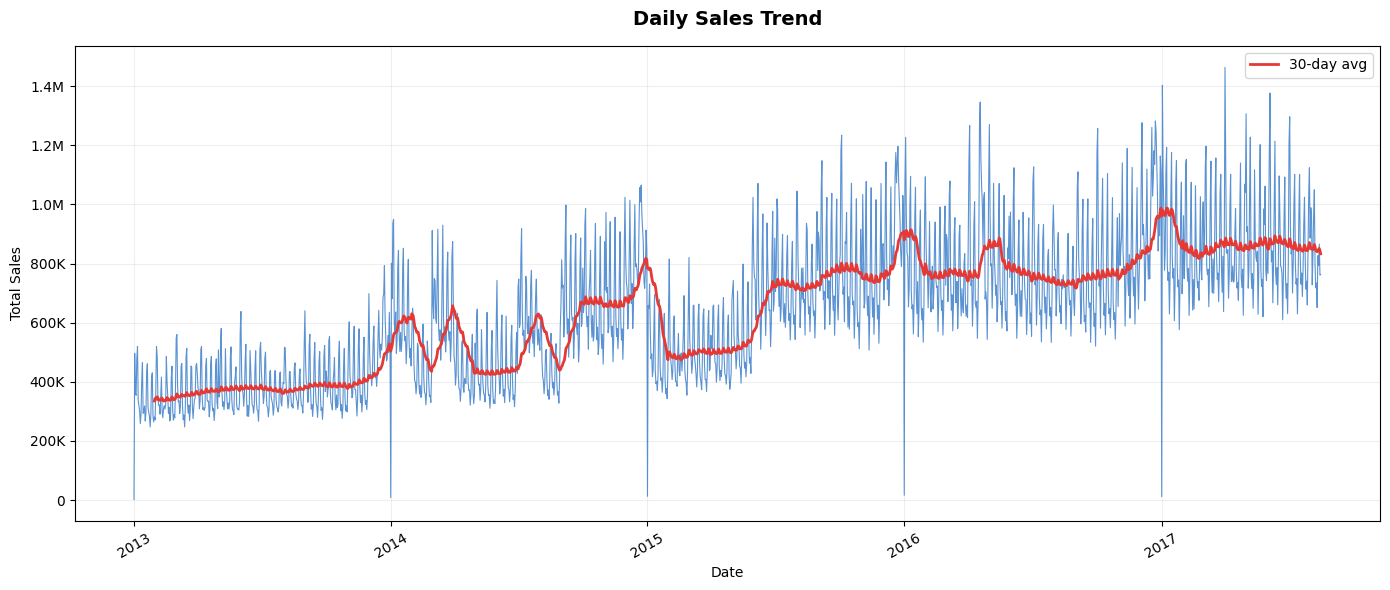

chart1_daily_sales_trend.png saved ✓


In [30]:

def fmt(x):
    if x >= 1e6: return f"{x/1e6:.1f}M"
    if x >= 1e3: return f"{x/1e3:.0f}K"
    return str(int(x))


fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(daily_sales['date'], daily_sales['sales'],
         color='#1565C0', linewidth=0.8, alpha=0.7)
ax1.plot(daily_sales['date'],
         daily_sales['sales'].rolling(30).mean(),
         color='#E53935', linewidth=2, label='30-day avg')
ax1.set_title('Daily Sales Trend', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Date'); ax1.set_ylabel('Total Sales')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax1.legend(fontsize=10); ax1.grid(alpha=0.2)
ax1.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('chart1_daily_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart1_daily_sales_trend.png saved ✓")
plt.close()

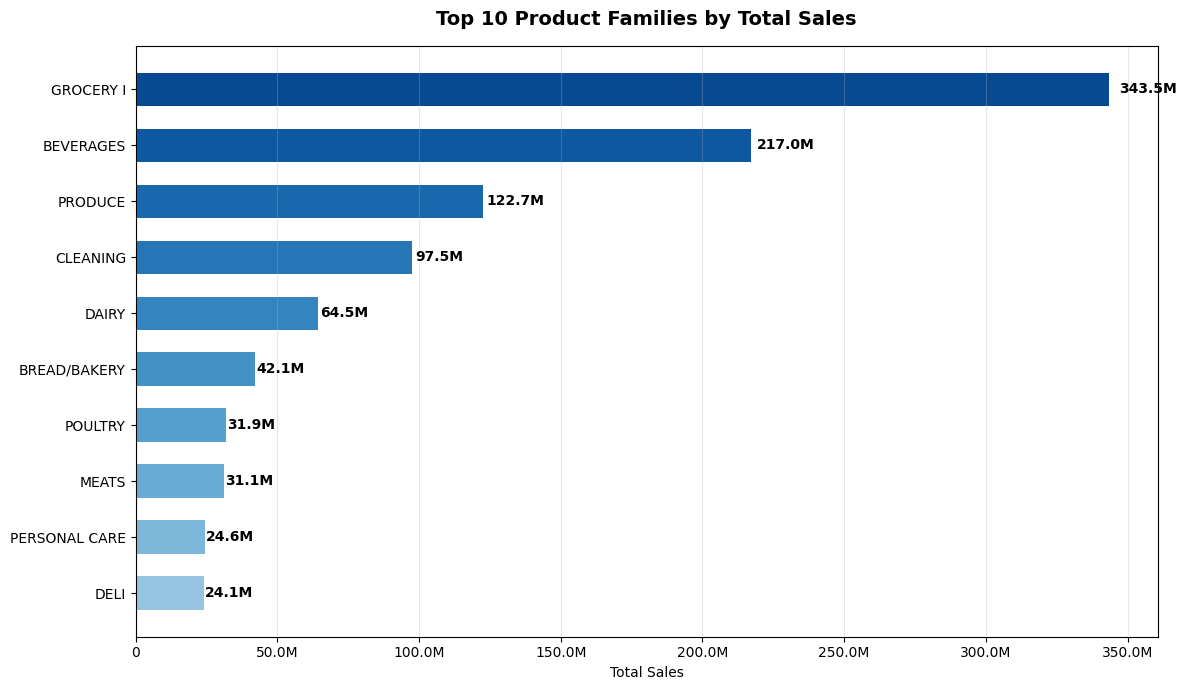

chart2_top_families.png saved ✓


In [31]:
# CHART 2 — Top 10 Product Families
fig2, ax2 = plt.subplots(figsize=(12, 7))
top10 = family_sales.head(10).sort_values(ascending=True)
bars2 = ax2.barh(top10.index, top10.values,
                  color=plt.cm.Blues(np.linspace(0.4, 0.9, 10)),
                  height=0.6)
ax2.set_title('Top 10 Product Families by Total Sales',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Total Sales')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax2.grid(axis='x', alpha=0.3)
for bar in bars2:
    ax2.text(bar.get_width()*1.01,
             bar.get_y()+bar.get_height()/2,
             fmt(bar.get_width()),
             va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_top_families.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart2_top_families.png saved ✓")
plt.close()


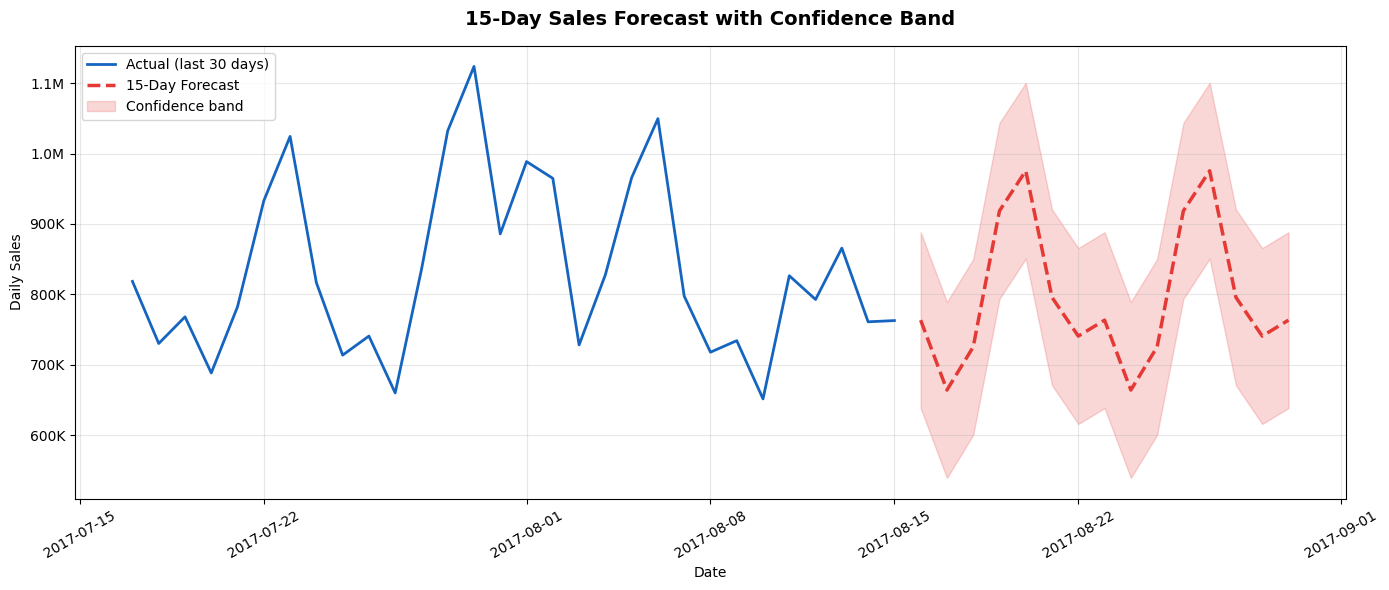

chart3_15day_forecast.png saved ✓


In [32]:
# CHART 3 — 15-Day Sales Forecast
fig3, ax3 = plt.subplots(figsize=(14, 6))
ax3.plot(daily_sales['date'].tail(30),
         daily_sales['sales'].tail(30),
         color='#1565C0', linewidth=2, label='Actual (last 30 days)')
ax3.plot(future_df['date'], future_df['forecast'],
         color='#E53935', linewidth=2.5,
         linestyle='--', label='15-Day Forecast')
ax3.fill_between(future_df['date'],
                  future_df['lower'], future_df['upper'],
                  alpha=0.2, color='#E53935', label='Confidence band')
ax3.set_title('15-Day Sales Forecast with Confidence Band',
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Date'); ax3.set_ylabel('Daily Sales')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax3.legend(fontsize=10); ax3.grid(alpha=0.3)
ax3.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('chart3_15day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart3_15day_forecast.png saved ✓")
plt.close()

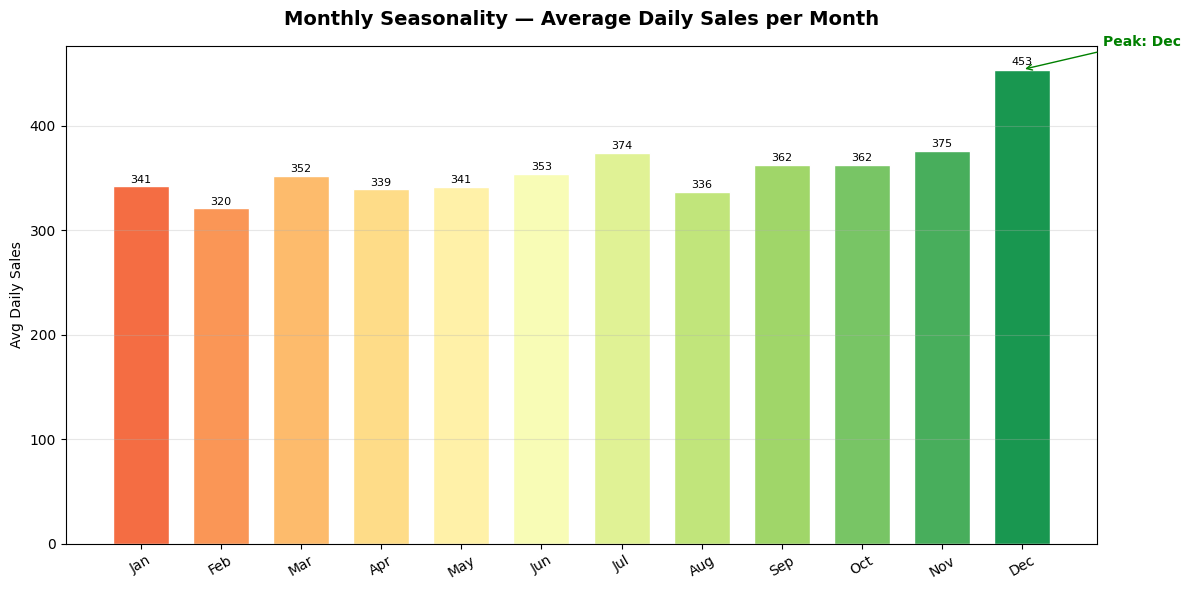

chart4_monthly_seasonality.png saved ✓


In [33]:
#CHART 4 — Monthly Seasonality
fig4, ax4 = plt.subplots(figsize=(12, 6))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
bars4 = ax4.bar(range(1,13), monthly_avg.values,
                color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 12)),
                width=0.7, edgecolor='white')
ax4.set_xticks(range(1,13))
ax4.set_xticklabels(month_names, rotation=30, fontsize=10)
ax4.set_title('Monthly Seasonality — Average Daily Sales per Month',
              fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('Avg Daily Sales')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax4.grid(axis='y', alpha=0.3)
# Highlight peak month
peak_month = monthly_avg.idxmax()
ax4.annotate(f'Peak: {month_names[peak_month-1]}',
             xy=(peak_month, monthly_avg[peak_month]),
             xytext=(peak_month+1, monthly_avg[peak_month]*1.05),
             fontsize=10, color='green', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green'))
for bar in bars4:
    ax4.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()*1.01,
             fmt(bar.get_height()),
             ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('chart4_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart4_monthly_seasonality.png saved ✓")
plt.close()

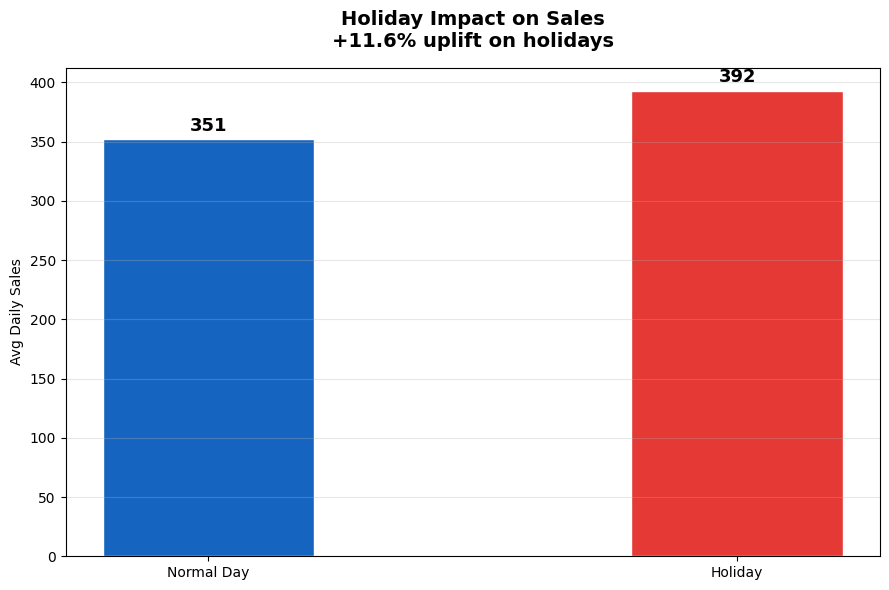

chart5_holiday_impact.png saved ✓


In [34]:
# CHART 5 — Holiday Impact
fig5, ax5 = plt.subplots(figsize=(9, 6))
bars5 = ax5.bar(['Normal Day', 'Holiday'],
                [holiday_comp[0], holiday_comp[1]],
                color=['#1565C0', '#E53935'],
                width=0.4, edgecolor='white')
ax5.set_title(f'Holiday Impact on Sales\n+{holiday_uplift:.1f}% uplift on holidays',
              fontsize=14, fontweight='bold', pad=15)
ax5.set_ylabel('Avg Daily Sales')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax5.grid(axis='y', alpha=0.3)
for bar in bars5:
    ax5.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()*1.02,
             fmt(bar.get_height()),
             ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_holiday_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart5_holiday_impact.png saved ✓")
plt.close()

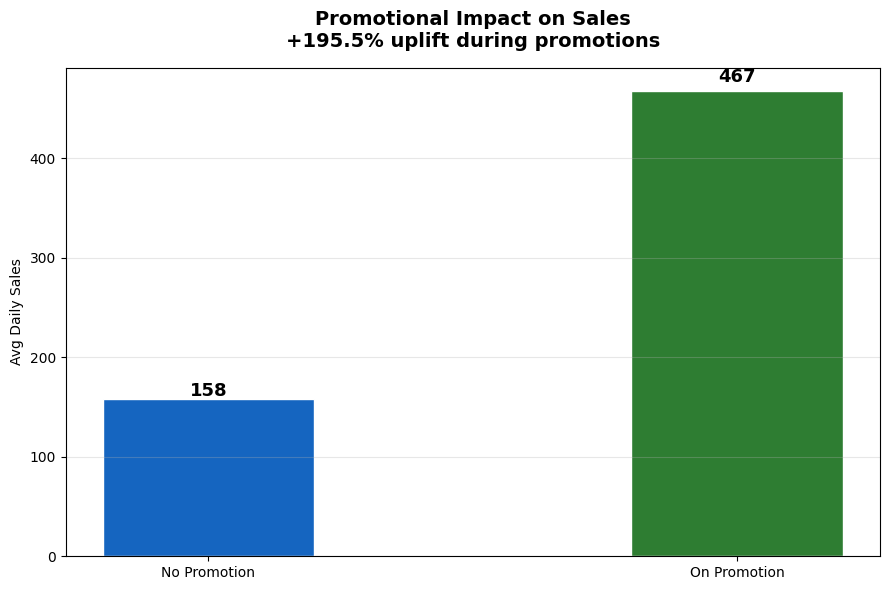

chart6_promo_impact.png saved ✓


In [35]:
# CHART 6 — Promotion Impact
fig6, ax6 = plt.subplots(figsize=(9, 6))
bars6 = ax6.bar(['No Promotion', 'On Promotion'],
                [promo_comp[0], promo_comp[1]],
                color=['#1565C0', '#2E7D32'],
                width=0.4, edgecolor='white')
ax6.set_title(f'Promotional Impact on Sales\n+{promo_uplift:.1f}% uplift during promotions',
              fontsize=14, fontweight='bold', pad=15)
ax6.set_ylabel('Avg Daily Sales')
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax6.grid(axis='y', alpha=0.3)
for bar in bars6:
    ax6.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()*1.02,
             fmt(bar.get_height()),
             ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_promo_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart6_promo_impact.png saved ✓")
plt.close()


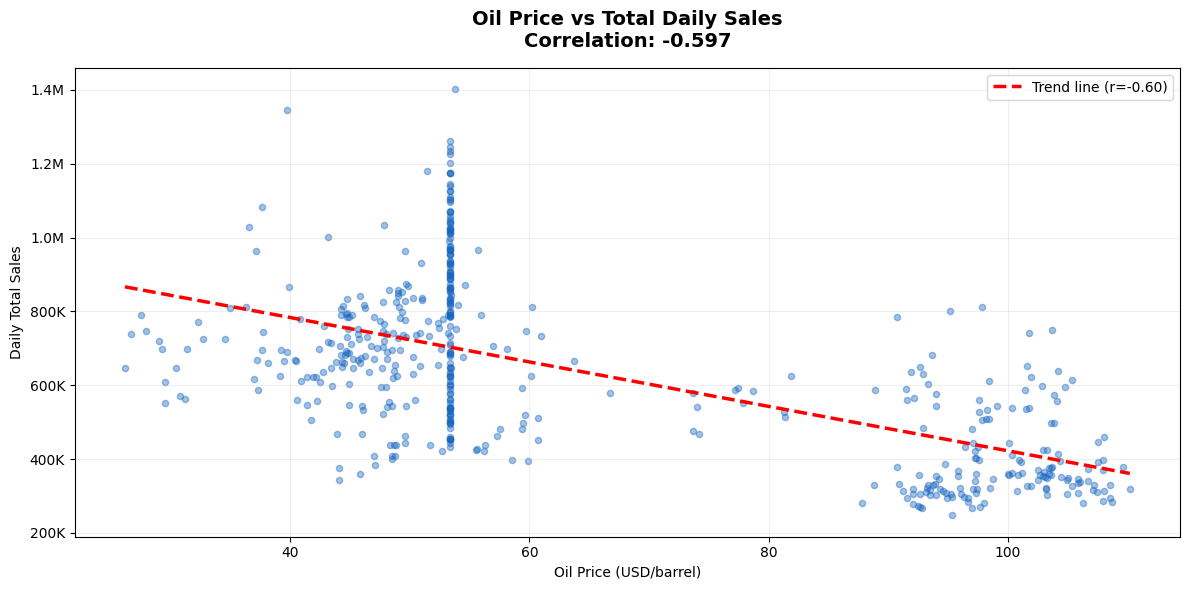

chart7_oil_vs_sales.png saved ✓


In [36]:
# CHART 7 — Oil Price vs Sales
fig7, ax7 = plt.subplots(figsize=(12, 6))
s = oil_daily.sample(500, random_state=42)
ax7.scatter(s['oil_price'], s['sales'],
            alpha=0.4, s=20, color='#1565C0')
z = np.polyfit(s['oil_price'], s['sales'], 1)
x_line = np.linspace(s['oil_price'].min(),
                      s['oil_price'].max(), 100)
ax7.plot(x_line, np.poly1d(z)(x_line), 'r--',
         linewidth=2.5, label=f'Trend line (r={oil_corr:.2f})')
ax7.set_title(f'Oil Price vs Total Daily Sales\nCorrelation: {oil_corr:.3f}',
              fontsize=14, fontweight='bold', pad=15)
ax7.set_xlabel('Oil Price (USD/barrel)')
ax7.set_ylabel('Daily Total Sales')
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax7.legend(fontsize=10); ax7.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('chart7_oil_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart7_oil_vs_sales.png saved ✓")
plt.close()

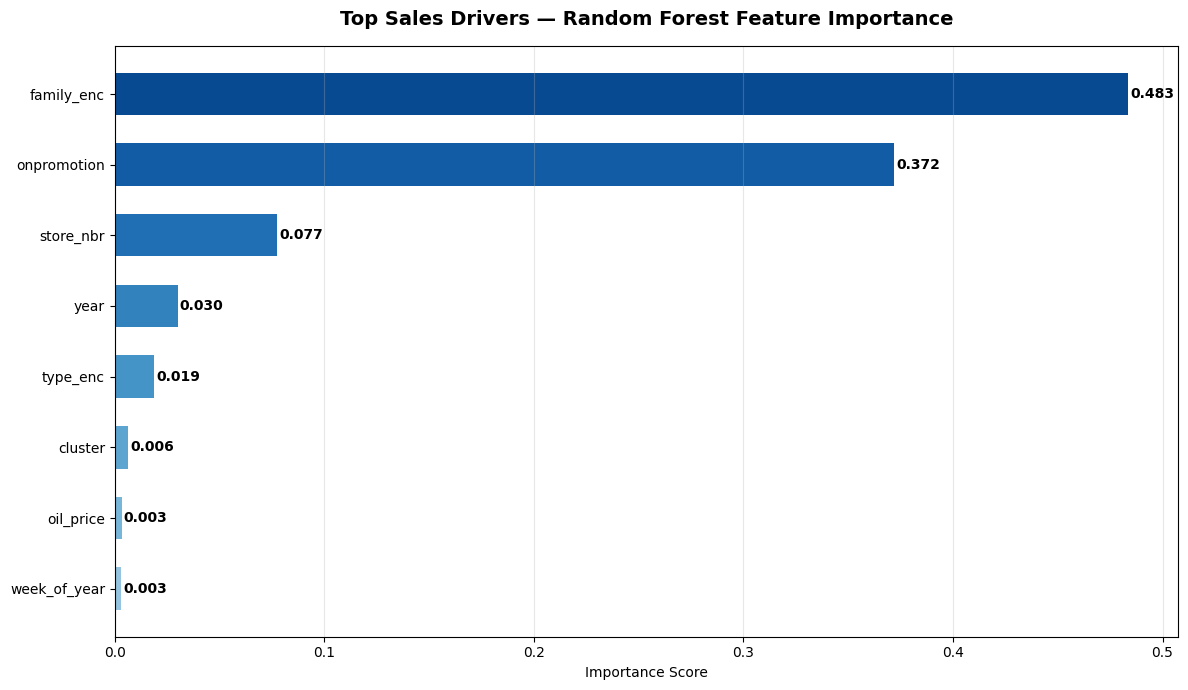

chart8_feature_importance.png saved ✓


In [38]:
# CHART 8 — Feature Importance
fig8, ax8 = plt.subplots(figsize=(12, 7))
top8 = imp_df.head(8).sort_values('Importance', ascending=True)
bars8 = ax8.barh(top8['Feature'], top8['Importance'],
                  color=plt.cm.Blues(np.linspace(0.4, 0.9, 8)),
                  height=0.6)
ax8.set_title('Top Sales Drivers — Random Forest Feature Importance',
              fontsize=14, fontweight='bold', pad=15)
ax8.set_xlabel('Importance Score')
ax8.grid(axis='x', alpha=0.3)
for bar in bars8:
    ax8.text(bar.get_width()+0.001,
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():.3f}",
             va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart8_feature_importance.png saved ✓")
plt.close()

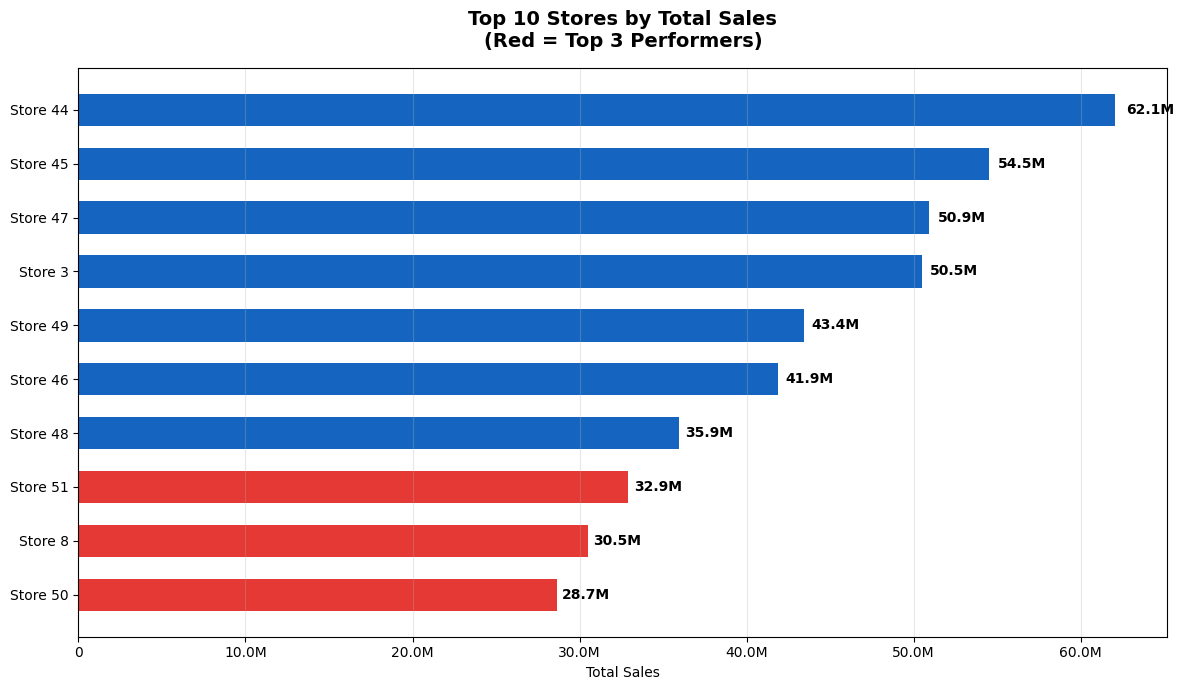

chart9_store_performance.png saved ✓


In [37]:
# CHART 9 — Store Performance
fig9, ax9 = plt.subplots(figsize=(12, 7))
top10s  = store_sales.head(10).sort_values(ascending=True)
colors9 = ['#E53935']*3 + ['#1565C0']*7
bars9   = ax9.barh(
    [f"Store {s}" for s in top10s.index],
    top10s.values,
    color=colors9, height=0.6)
ax9.set_title('Top 10 Stores by Total Sales\n(Red = Top 3 Performers)',
              fontsize=14, fontweight='bold', pad=15)
ax9.set_xlabel('Total Sales')
ax9.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt(x)))
ax9.grid(axis='x', alpha=0.3)
for bar in bars9:
    ax9.text(bar.get_width()*1.01,
             bar.get_y()+bar.get_height()/2,
             fmt(bar.get_width()),
             va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart9_store_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart9_store_performance.png saved ✓")
plt.close()

In [40]:
print("Exporting CSV files for Power BI...")

# CSV 1 — Daily sales
daily_sales[['date','sales']].to_csv('ps_daily_sales.csv', index=False)
print("ps_daily_sales.csv ✓")

# CSV 2 — Family sales
family_sales.reset_index().rename(
    columns={'sales':'total_sales'}
).to_csv('ps_family_sales.csv', index=False)
print("ps_family_sales.csv ✓")

# CSV 3 — Store performance
train_df.groupby('store_nbr').agg(
    total_sales = ('sales','sum'),
    city        = ('city','first'),
    store_type  = ('type','first')
).reset_index().to_csv('ps_store_performance.csv', index=False)
print("ps_store_performance.csv ✓")

# CSV 4 — Monthly seasonality
pd.DataFrame({
    'month_num':       range(1,13),
    'month_name':      ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'],
    'avg_daily_sales': monthly_avg.values.round(2)
}).to_csv('ps_monthly_seasonality.csv', index=False)
print("ps_monthly_seasonality.csv ✓")

# CSV 5 — 15 day forecast
future_df[['date','forecast','upper','lower']].to_csv(
    'ps_15day_forecast.csv', index=False)
print("ps_15day_forecast.csv ✓")

# CSV 6 — Model results
pd.DataFrame({
    'model': list(results.keys()),
    'rmse':  [round(v,4) for v in results.values()],
    'best':  ['Yes' if k==best_model_name else 'No'
              for k in results.keys()]
}).sort_values('rmse').to_csv('ps_model_results.csv', index=False)
print("ps_model_results.csv ✓")

# CSV 7 — Holiday impact
pd.DataFrame({
    'day_type':  ['Normal Day','Holiday'],
    'avg_sales': [round(holiday_comp[0],2), round(holiday_comp[1],2)],
    'uplift_pct':[0, round(holiday_uplift,2)]
}).to_csv('ps_holiday_impact.csv', index=False)
print("ps_holiday_impact.csv ✓")

# CSV 8 — Promo impact
pd.DataFrame({
    'promo_status':['No Promotion','On Promotion'],
    'avg_sales':   [round(promo_comp[0],2), round(promo_comp[1],2)],
    'uplift_pct':  [0, round(promo_uplift,2)]
}).to_csv('ps_promo_impact.csv', index=False)
print("ps_promo_impact.csv ✓")

# CSV 9 — Oil vs sales
oil_daily[['date','sales','oil_price']].to_csv(
    'ps_oil_vs_sales.csv', index=False)
print("ps_oil_vs_sales.csv ✓")

print("\nAll CSVs exported for Power BI ✓")


Exporting CSV files for Power BI...
ps_daily_sales.csv ✓
ps_family_sales.csv ✓
ps_store_performance.csv ✓
ps_monthly_seasonality.csv ✓
ps_15day_forecast.csv ✓
ps_model_results.csv ✓
ps_holiday_impact.csv ✓
ps_promo_impact.csv ✓
ps_oil_vs_sales.csv ✓

All CSVs exported for Power BI ✓


In [46]:
# SHORT REPORT
print(f"""
QUERY:
  What will grocery sales be for the next 15 days
  and what factors drive demand?

DATA:
  {len(train_df):,} records | {train_df['store_nbr'].nunique()} stores |
  {train_df['family'].nunique()} product families
  Date: {train_df['date'].min().date()} to {train_df['date'].max().date()}

KEY FINDINGS:
  1. {family_sales.index[0]} is top family —
     {family_sales.iloc[0]/family_sales.sum()*100:.1f}% of all sales

  2. Promotions drive +{promo_uplift:.1f}% uplift —
     products on promotion sell 3x more units

  3. Holidays drive +{holiday_uplift:.1f}% uplift —
     increase stock ahead of public holidays

  4. Oil prices show {oil_corr:.3f} correlation with sales —
     rising oil = falling grocery spend

  5. Peak month: December | Lowest month: February

MODEL RESULTS:
  Best model:      {best_model_name} (RMSE={best_rmse:.4f})
  15-day forecast: {future_df['forecast'].sum():,.0f} units total
  Daily average:   {future_df['forecast'].mean():,.0f} units/day

RECOMMENDATION:
  Always include promotional calendar as primary input
  to any demand forecast. Buffer stock by +20% ahead
  of promotions and +15% ahead of public holidays.
""")


QUERY:
  What will grocery sales be for the next 15 days
  and what factors drive demand?

DATA:
  3,000,888 records | 54 stores |
  33 product families
  Date: 2013-01-01 to 2017-08-15

KEY FINDINGS:
  1. GROCERY I is top family —
     32.0% of all sales

  2. Promotions drive +195.5% uplift —
     products on promotion sell 3x more units

  3. Holidays drive +11.6% uplift —
     increase stock ahead of public holidays

  4. Oil prices show -0.597 correlation with sales —
     rising oil = falling grocery spend

  5. Peak month: December | Lowest month: February

MODEL RESULTS:
  Best model:      Random Forest (RMSE=1.0935)
  15-day forecast: 11,928,643 units total
  Daily average:   795,243 units/day

RECOMMENDATION:
  Always include promotional calendar as primary input
  to any demand forecast. Buffer stock by +20% ahead
  of promotions and +15% ahead of public holidays.

